# Covariance Matrices in High Dimensions 

### Sang-Yun Oh

## Covariance Matrix

* Covariance matrix is defined as
$$
\Sigma=E(\boldsymbol{X}-\boldsymbol{\mu})(\boldsymbol{X}-\boldsymbol{\mu})^{\prime}=\left(\sigma_{i j}\right),
$$

* Sample covariance matrix is
$$
\mathbf{S}=\frac{1}{n} \sum_{i=1}^{n}\left(\boldsymbol{X}_{i}-\overline{\boldsymbol{X}}\right)\left(\boldsymbol{X}_{i}-\overline{\boldsymbol{X}}\right)^{\prime},
$$
* Other types of covariance estimates

### Covariance Matrices in Practice

* Stocks: $p=4300+$ companies and 20 days per month  
    Relationship between stocks (volatility structure)

* Genomics: $p\approx 20000$ genes and 100s of subjects  
    Co-expression of genes (gene relevance network)

![Gene Co-expression Network](images/gene-regulatory-network.jpg)

Shows protein-protein interaction network. Source: https://doi.org/10.1038/npjschz.2016.12

* Neuroimaging: $p=90000$ voxels (or hundreds of aggregated ROIs) and thousands of time points  
    Functional connectivity network

![Functional Connectivity](images/neuro-functional-structural-connectivity.png)

Source: https://doi.org/10.1073/pnas.1912034117

* Ecology: $p=23$ environmental variables and $n=12$ locations  
    Community abundance (Warton 2008)
    
**Data are often high dimensional**

### Other Covariance Matrix Uses

* Markowitz Portfolio Problem (encodes market volatility)
* Regression (OLS)  
$$
\widehat{\beta}_{\text {OLS}}=\left(\boldsymbol{X}^{\prime} \boldsymbol{X}\right)^{-1} \boldsymbol{X}^{\prime} \boldsymbol{Y}
$$
* Canonical Correlation Analysis (CCA): associations among two sets of variables ([examples](https://stats.idre.ucla.edu/r/dae/canonical-correlation-analysis/))
* Input to clustering algorithm
* Inverse of $\Sigma$ often needed but doesn't exist in high dimensional setting


### Visualize volatility structure

* Heatmap visualization of covariance and correlation

In [1]:
#| code-fold: true
import yfinance as yf
import pandas as pd

store = pd.HDFStore('data/yfinance-data-store.h5')

if 'rawdata' in store:
    rawdata = store['rawdata']
    print('Data loaded from store')
else:
    print('Downloading data from Yahoo Finance')
    print('set auto_adjust=False to get adjusted closing price as separate column')
    rawdata = yf.download(dowjones_components, start="2000-01-01", end="2025-11-01", auto_adjust=True)
    store['rawdata'] = rawdata

logret = store['logret'].dropna()

HDF5ExtError: HDF5 error back trace

  File "H5F.c", line 827, in H5Fopen
    unable to synchronously open file
  File "H5F.c", line 788, in H5F__open_api_common
    unable to open file
  File "H5VLcallback.c", line 3680, in H5VL_file_open
    open failed
  File "H5VLcallback.c", line 3514, in H5VL__file_open
    open failed
  File "H5VLnative_file.c", line 128, in H5VL__native_file_open
    unable to open file
  File "H5Fint.c", line 1963, in H5F_open
    unable to lock the file
  File "H5FD.c", line 2402, in H5FD_lock
    driver lock request failed
  File "H5FDsec2.c", line 956, in H5FD__sec2_lock
    unable to lock file, errno = 11, error message = 'Resource temporarily unavailable'

End of HDF5 error back trace

Unable to open/create file 'data/yfinance-data-store.h5'

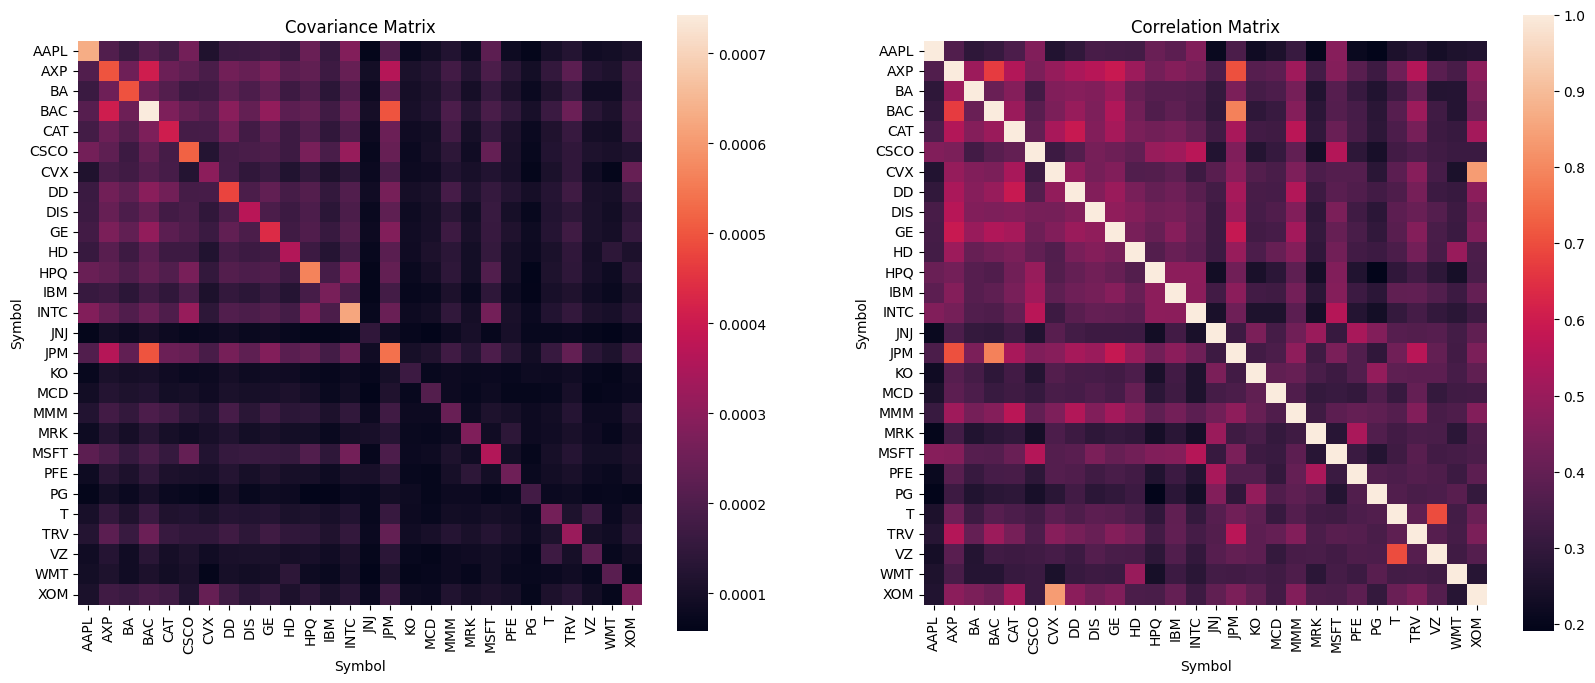

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(logret.cov(),  square=True, ax=ax[0]).set_title('Covariance Matrix')
sns.heatmap(logret.corr(), square=True, ax=ax[1]).set_title('Correlation Matrix');
# fig.show();

* Reordering variables group similar stocks together

/opt/conda/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


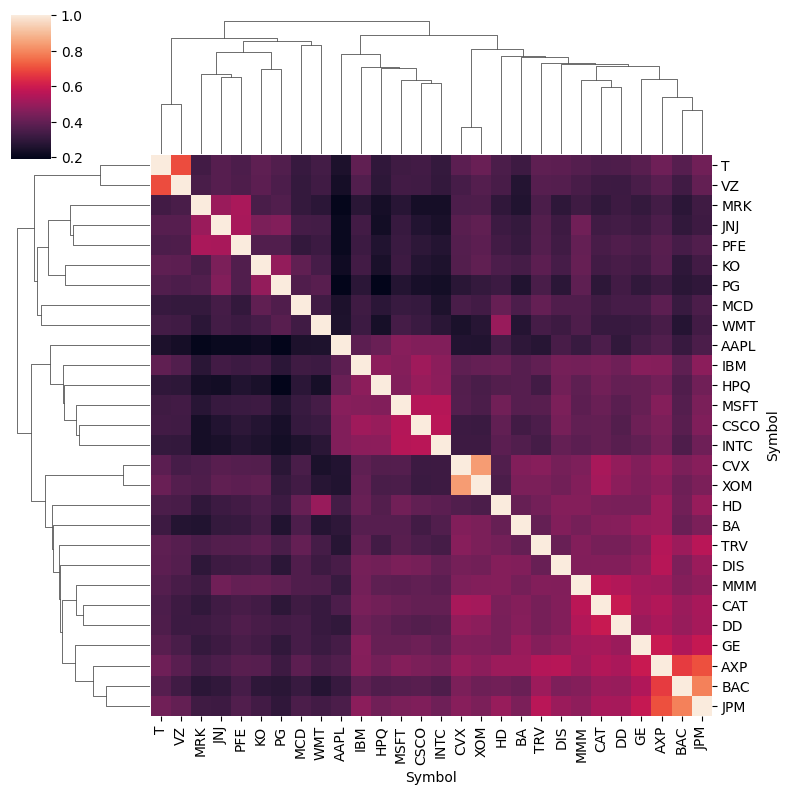

In [ ]:
clmap = sns.clustermap(logret.corr(), square=True, figsize=(8, 8));
ordering = clmap.dendrogram_col.reordered_ind # save the hierarchical clustering generated variable ordering

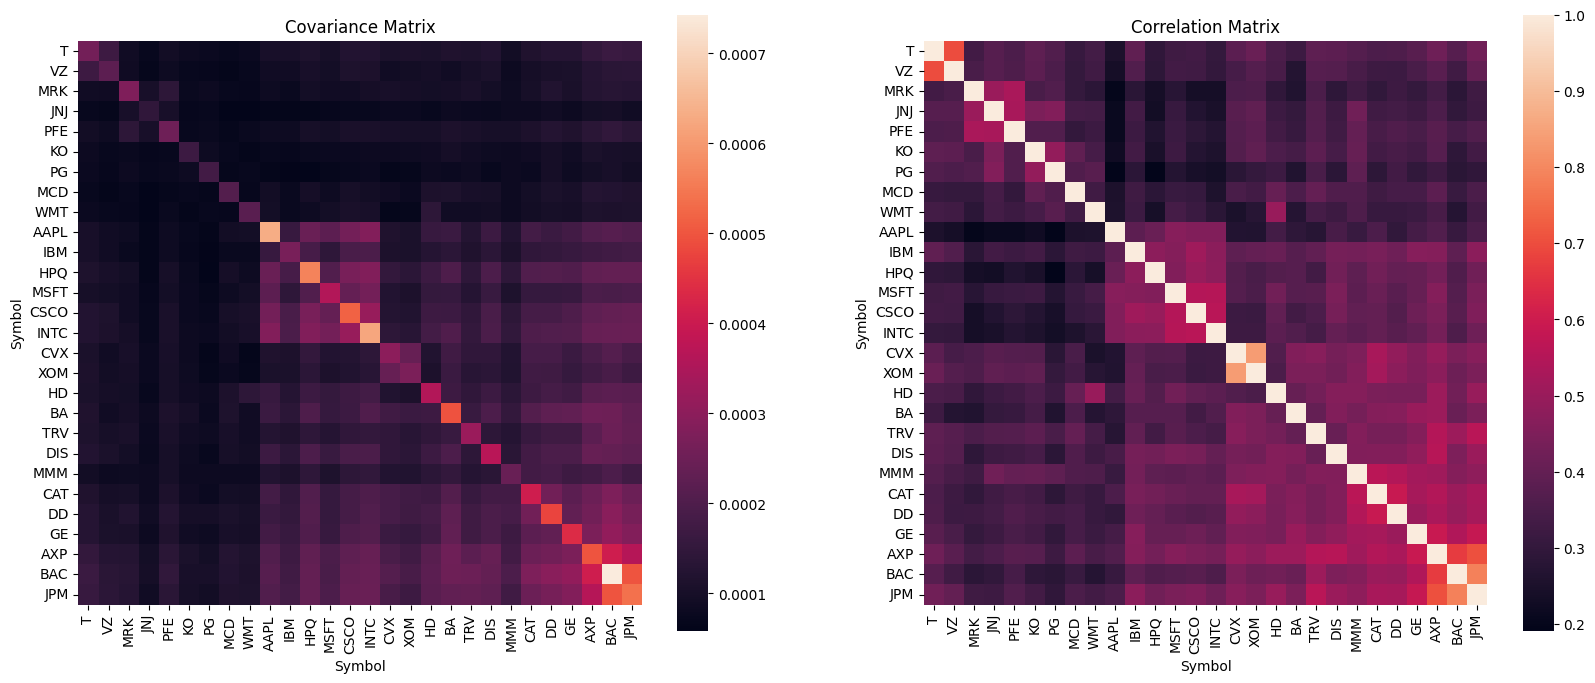

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(logret.cov().iloc[ordering, ordering],  square=True, ax=ax[0]).set_title('Covariance Matrix')
sns.heatmap(logret.corr().iloc[ordering, ordering], square=True, ax=ax[1]).set_title('Correlation Matrix');
# fig.show()


## Visualization of Relationships

* Correlations are stricly pairwise quantities (what about other stocks?)
* Inverse covariance

In [ ]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaled_df = scaler.fit_transform(logret.dropna().values)
scaled_df = pd.DataFrame(scaled_df, columns=logret.columns, index=logret.index)

### Correlation Matrix: Year 2020

/opt/conda/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


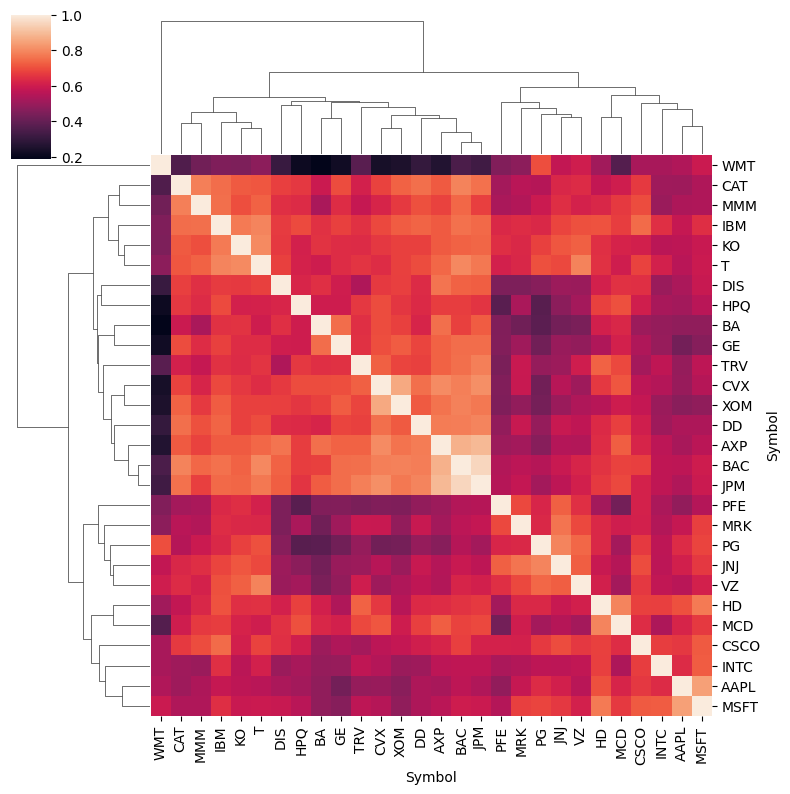

In [ ]:
clmap = sns.clustermap(scaled_df.loc['2020':'2020'].corr(), square=True, figsize=(8, 8));
ordering = clmap.dendrogram_col.reordered_ind # save the hierarchical clustering generated variable ordering

### Correlation Matrix: 2019 vs. 2020

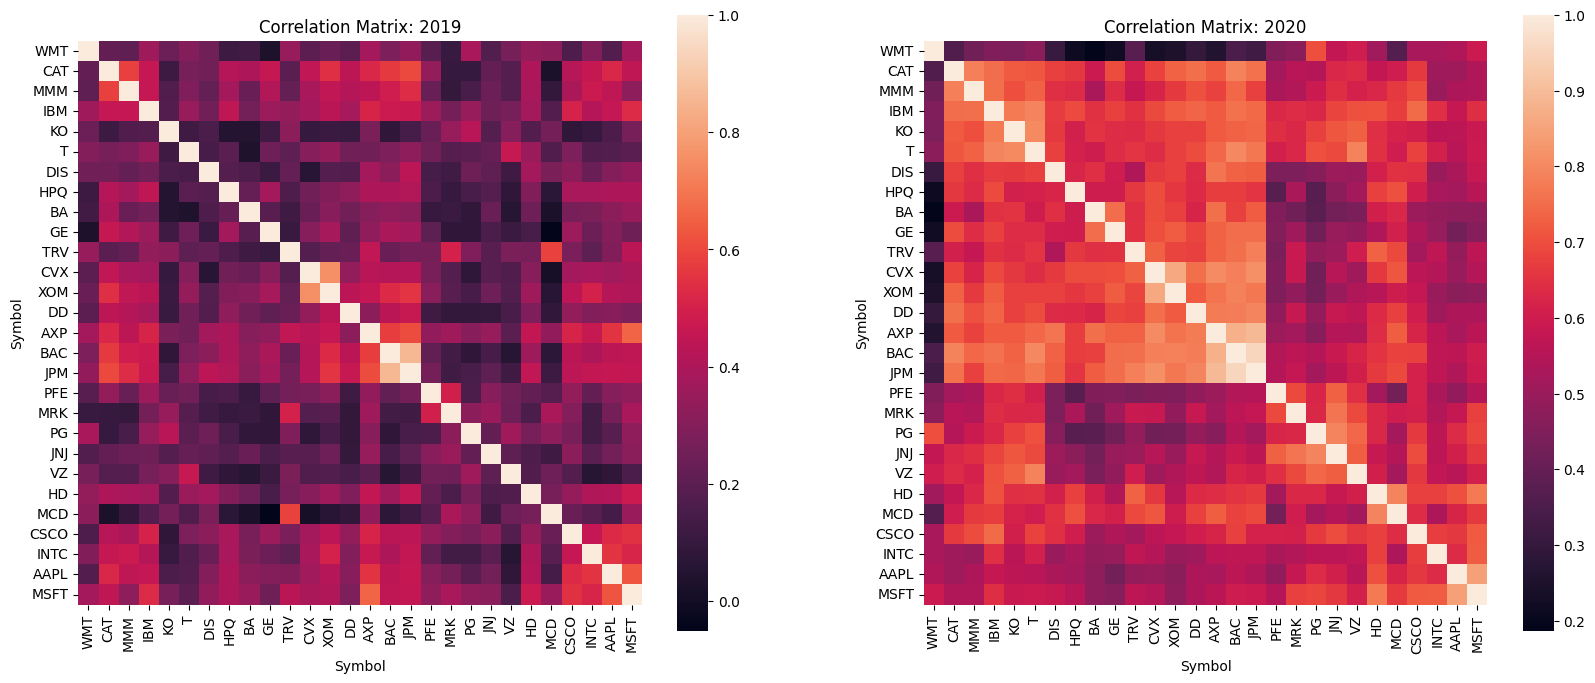

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(scaled_df.loc['2019':'2019'].corr().iloc[ordering, ordering],  square=True, ax=ax[0]).set_title('Correlation Matrix: 2019')
sns.heatmap(scaled_df.loc['2020':'2020'].corr().iloc[ordering, ordering],  square=True, ax=ax[1]).set_title('Correlation Matrix: 2020');
# fig.show()

### Mathematical Properties

* Matrix $\Sigma$ is symmetric
* All eigenvalues are nonnegative
* Nonnegative definite
* If singular, dimensionality can be reduced (assuming enough data is used)

### Difficulty with Estimation of Covariance Matrices

* High dimensionality: $O(p^2)$ parameters grows faster than available samples ($n \ll p$)
* Sample deficiency: $\mathbf{S}$ is singular when $p>n$; poorly conditioned when $p$ close to $n$
* Eigenvalue distortion: extreme spread, noisy small eigenvalues (Marchenko–Pastur effects)
* Computational burden: forming/storing $\mathbf{S}$ is $O(p^2)$ memory, eigendecompositions $O(p^3)$
* Stability: high sensitivity to outliers, heavy tails, regime shifts, and nonstationarity
* Spurious correlations: many pairwise correlations appear significant by chance
* Missing data and asynchronous sampling (finance, genomics) complicate estimation
* Interpretability: dense estimates hinder structural insight (networks, factor structure)
* Downstream impact: inversion instability propagates to regression, portfolio optimization, CCA

## Regularized Estimation

* Eigenvalue structure (Ledoit-Wolf, Condition number regularization)
* Sparsity pattern (Graphical models)
* Structural assumptions (banding, tapering, low-rank)

All stabilize estimates (bias variance trade off)

### Eigen-structure changes


* Eigenvector regularization (sparse PCA, SVD, etc)
* Ledoit-Wolf Estimator (Ledoit and Wolf, 2004)
  $$
  \widehat{\mathbf{\Sigma}}=\alpha I+(1-\alpha) \mathbf{S}
  $$
* Condition number regularization (Won et al., 2009)
  $$
  \begin{array}{ll}
  \operatorname{maximize} & l(\Sigma) \\
  \text { subject to } & \operatorname{cond}(\Sigma) \leq \kappa_{\max },
  \end{array}
  $$  
  where $l(\Sigma)$ is the Gaussian Likelihood
- Ridge regression: $\min_\beta \|Y - X\beta\|^2 +\gamma\|\beta\|_2^2$
  $$
  \widehat{\beta}_{\text {Ridge}}=\left(X^{\prime} X + \gamma I\right)^{-1} X^{\prime} Y
  $$

## Compare Eigenvalues

* Different estimates perform different regularization
* There are similairies as well as differences

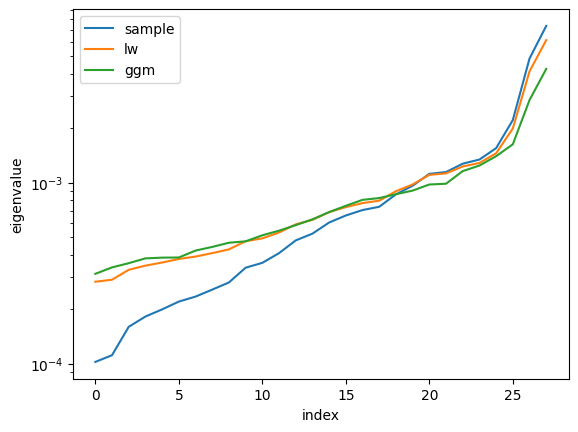

In [ ]:
eigval_sample = npl.eigvalsh(cov_sample)
eigval_lw = npl.eigvalsh(cov_lw)
eigval_ggm = npl.eigvalsh(cov_ggm)

allevals = pd.DataFrame({
    "sample": np.real(eigval_sample),
    "lw": eigval_lw,
    "ggm": eigval_ggm
})
ax = allevals.plot(logy=True)
ax.set_xlabel('index')
ax.set_ylabel('eigenvalue');

### Sparsity Assumption (Graphical Model)

* $\mathbf{\Omega}=\mathbf{\Sigma}^{-1}$ appear in many situations
* $\mathbf{\Omega}$ can be regularized directly

* Assume $\boldsymbol{X}_{1}, \ldots, \boldsymbol{X}_{n} \sim N_{p}(\boldsymbol{0}, \boldsymbol{\Sigma})$ and 
$$
L(\boldsymbol{\Sigma})=\frac{1}{(2 \pi)^{n p / 2}|\boldsymbol{\Sigma}|^{n / 2}} \exp \left\{-\frac{1}{2} \sum_{i=1}^{n} \boldsymbol{X}_{i}^{\prime} \boldsymbol{\Sigma}^{-1} \boldsymbol{X}_{i}\right\} .
$$

* Compute $\boldsymbol{\Omega}$:
$$
\ell_{P}(\boldsymbol{\Omega})=\log |\boldsymbol{\Omega}|-\operatorname{tr}(\mathbf{S} \boldsymbol{\Omega})-\lambda\|\boldsymbol{\Omega}\|_{1},
$$

Reference: [High‐Dimensional Covariance Estimation](https://ucsb-primo.hosted.exlibrisgroup.com/permalink/f/1egv95m/01UCSB_ALMA51276966020003776) by Mohsen Pourahmadi

### Multivariate Gaussian

#### The Setup: Partitioning the Vectors and Matrices

Let $x$ be a $D$-dimensional Gaussian random vector with mean $\mu$ and covariance $\Sigma$. We partition $x$ into two disjoint subsets, $x_a$ and $x_b$ (where we want to find the distribution of $x_a$ given $x_b$).

$$
x = \begin{bmatrix} x_a \\ x_b \end{bmatrix}, \quad
\mu = \begin{bmatrix} \mu_a \\ \mu_b \end{bmatrix}
$$

The joint distribution is defined as $p(x) = \mathcal{N}(x | \mu, \Sigma)$.

---

#### 1. In Terms of the Covariance Matrix ($\Sigma$)

We partition the covariance matrix $\Sigma$ to correspond with $x_a$ and $x_b$:

$$
\Sigma = \begin{bmatrix} \Sigma_{aa} & \Sigma_{ab} \\ \Sigma_{ba} & \Sigma_{bb} \end{bmatrix}
$$

The conditional distribution $p(x_a | x_b)$ is also a Gaussian distribution $\mathcal{N}(x_a | \mu_{a|b}, \Sigma_{a|b})$.

##### The Conditional Mean
The mean of $x_a$ is adjusted by the deviation of $x_b$ from its mean, scaled by the correlation between the two:

$$
\mu_{a|b} = \mu_a + \Sigma_{ab}\Sigma_{bb}^{-1}(x_b - \mu_b)
$$

##### The Conditional Covariance
The uncertainty in $x_a$ is reduced by the knowledge of $x_b$. This is mathematically represented by the **Schur Complement** of $\Sigma_{bb}$ in $\Sigma$:

$$
\Sigma_{a|b} = \Sigma_{aa} - \Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}
$$



> **Note:** Calculating the conditional distribution using the covariance matrix requires computing the inverse of $\Sigma_{bb}$. If $x_b$ is high-dimensional, this is computationally expensive.

#### 2. In Terms of the Precision Matrix ($\Omega$)

The Precision matrix (also called the information matrix) is the inverse of the covariance matrix: $\Omega = \Sigma^{-1}$. We partition $\Omega$ similarly:

$$
\Omega = \begin{bmatrix} \Omega_{aa} & \Omega_{ab} \\ \Omega_{ba} & \Omega_{bb} \end{bmatrix}
$$

Note that because the inverse of a block matrix involves complex interactions between blocks, $\Omega_{aa}$ is **not** simply $\Sigma_{aa}^{-1}$.

When expressing the conditional distribution $p(x_a | x_b)$ using the precision matrix, the formulas usually become simpler and computationally more efficient, specifically for the covariance.

##### The Conditional Mean
$$
\mu_{a|b} = \mu_a - \Omega_{aa}^{-1}\Omega_{ab}(x_b - \mu_b)
$$

##### The Conditional Covariance
Here is the elegant property of the precision matrix: The conditional precision is simply the corresponding block of the joint precision matrix. Therefore, the conditional covariance is just the inverse of that block:

$$
\Sigma_{a|b} = \Omega_{aa}^{-1}
$$

#### Summary Comparison

| Parameter | Using Covariance Matrix ($\Sigma$) | Using Precision Matrix ($\Omega$) |
| :--- | :--- | :--- |
| **Conditional Mean** ($\mu_{a \mid b}$) | $\mu_a + \Sigma_{ab}\Sigma_{bb}^{-1}(x_b - \mu_b)$ | $\mu_a - \Omega_{aa}^{-1}\Omega_{ab}(x_b - \mu_b)$ |
| **Conditional Covariance** ($\Sigma_{a \mid b}$) | $\Sigma_{aa} - \Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}$ | $\Omega_{aa}^{-1}$ |

### Two-dimensional example: $x=(x_a,x_b)^\top$

Assume
$$
x \sim \mathcal N(\mu,\Sigma),\qquad
\mu=\begin{bmatrix}\mu_a\\ \mu_b\end{bmatrix},\quad
\Sigma=
\begin{bmatrix}
\sigma_{aa} & \sigma_{ab}\\
\sigma_{ab} & \sigma_{bb}
\end{bmatrix}.
$$

For the conditional distribution of $x_a\mid x_b$:
$$
x_a\mid x_b \sim \mathcal N\!\left(\mu_{a\mid b},\,\sigma_{a\mid b}\right).
$$

Using **covariance matrix elements**:
$$
\mu_{a\mid b}
= \mu_a + \frac{\sigma_{ab}}{\sigma_{bb}}(x_b-\mu_b),
$$
$$
\sigma_{a\mid b}
= \sigma_{aa}-\frac{\sigma_{ab}^2}{\sigma_{bb}}.
$$

Now let $\Omega=\Sigma^{-1}$ be the precision matrix:
$$
\Omega=
\begin{bmatrix}
\omega_{aa} & \omega_{ab}\\
\omega_{ab} & \omega_{bb}
\end{bmatrix}.
$$

Using **precision matrix elements**:
$$
\mu_{a\mid b}
= \mu_a-\frac{\omega_{ab}}{\omega_{aa}}(x_b-\mu_b),
$$
$$
\sigma_{a\mid b}
= \omega_{aa}^{-1}.
$$

So in 2D, conditioning is a scalar linear update to the mean, and the conditional variance is the Schur complement (equivalently, $1/\omega_{aa}$).


**Key Insight:**
* **Marginalization** is easy with the **Covariance** matrix (you just take the sub-block $\Sigma_{aa}$).
* **Conditioning** is easy with the **Precision** matrix (you just take the sub-block $\Omega_{aa}$ and invert it).
* Zeros in the **Covariance** matrix imply *marginal* independence.
* Zeros in the **Precision** matrix imply *conditional* independence (essential for Gaussian Markov Random Fields).


## Numerical Experiments

In [ ]:
import pandas as pd
import numpy as np

# store = pd.HDFStore('data/yfinance-data-store.h5')
logret = store['logret'].dropna().head(100)

### Sample Covariance Matrix

$$
\mathbf{S}=\frac{1}{n} \sum_{i=1}^{n}\left(\boldsymbol{X}_{i}-\overline{\boldsymbol{X}}\right)\left(\boldsymbol{X}_{i}-\overline{\boldsymbol{X}}\right)^{\prime},
$$

* MLE of covariance matrix for Gaussian data
* Singular in high dimensional setting: Zero eigenvalues 
* When $p>n$, other covariance estimates are needed

In [ ]:

import sklearn.covariance as skcov
import sklearn.model_selection as sksel
import numpy.linalg as npl

cov_sample = skcov.empirical_covariance(logret)

### Ledoit-Wolf Estimator 
$$
\Sigma_{\text {LW}}=(1-\alpha) \mathbf{S}+\alpha \frac{\operatorname{Tr} \mathbf{S}}{p} \text { I }
$$

* Ledoit and Wolf, 2004 ([documentation page](https://scikit-learn.org/stable/modules/covariance.html#shrunk-covariance))
* Weighted average between sample covariance and identity (times average eigenvalue)

In [ ]:
cov_lw, shrinkage_lw = skcov.ledoit_wolf(logret)

In [ ]:
shrinkage_lw

np.float64(0.19241357306442586)

* Large eigenvalues decrease
* Zero eigenvalues increase (not sigular) 

### Graphical Model

In [ ]:
# !pip install bokeh==2.4.1
# !pip install networkx
# !pip install robust-selection

In [ ]:
edge_model = skcov.GraphicalLassoCV(n_refinements=2)
edge_model.fit(logret.head(30))
omega = edge_model.precision_.copy()
cov_ggm = npl.inv(edge_model.precision_)

/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [ ]:
from bokeh.io import show, output_file, output_notebook
from bokeh.models import (BoxSelectTool, Circle, EdgesAndLinkedNodes, 
                          HoverTool, MultiLine, NodesAndLinkedEdges, 
                          Plot, Range1d, TapTool, LabelSet, 
                          ColumnDataSource)
from bokeh.plotting import from_networkx
from bokeh.palettes import Spectral4
output_notebook()

import networkx as nx
G = nx.from_pandas_adjacency(pd.DataFrame(omega, columns=logret.columns.to_list(), index=logret.columns.to_list()))

Loading BokehJS ...

In [ ]:
plot = Plot(width=600, height=600,
            x_range=Range1d(-1.1,1.1), y_range=Range1d(-1.1,1.1))
plot.title.text = "Dow Jones Component Stock Graphical Models"

graph_renderer = from_networkx(G, nx.circular_layout, scale=1, center=(0,0))

graph_renderer.node_renderer.glyph = Circle(radius=0.05, fill_color=Spectral4[0])
graph_renderer.node_renderer.selection_glyph = Circle(radius=0.05, fill_color=Spectral4[2])

graph_renderer.edge_renderer.glyph = MultiLine(line_color="#CCCCCC", line_alpha=0.8, line_width=5)
graph_renderer.edge_renderer.selection_glyph = MultiLine(line_color=Spectral4[2], line_width=5)

graph_renderer.selection_policy = NodesAndLinkedEdges()
graph_renderer.inspection_policy = EdgesAndLinkedNodes()

plot.add_tools(HoverTool(tooltips=None), TapTool(), BoxSelectTool())
plot.renderers.append(graph_renderer)

# add labels
pos = nx.circular_layout(G)
x, y=zip(*pos.values())

source = ColumnDataSource({'x':x,'y':y,'ticker':logret.columns.to_list()})
labels = LabelSet(x='x', y='y', text='ticker', source=source)

plot.renderers.append(labels)

show(plot)

Regularization makes small eigenvalues larger (away from zero) and large eigenvalues smaller.

In [ ]:
store['logret'] = logret
store.close()